In [57]:
!pip install Pandas
!pip install Matplotlib
!pip install Seaborn
!pip install Numpy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [58]:
#3 In your Python notebook, establish the connection with your analysis file stored in GITHUB repo and bring the data into a dataframe.
df = pd.read_csv('https://raw.githubusercontent.com/raffson123/311Service/refs/heads/main/311_Service_Requests_from_2019May.csv')

/tmp/ipykernel_21104/2335281884.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/raffson123/311Service/refs/heads/main/311_Service_Requests_from_2019May.csv')


In [59]:
#4  Find the total number of rows and columns and their data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69637 entries, 0 to 69636
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unique Key              69637 non-null  int64  
 1   Created Date            69637 non-null  object 
 2   Closed Date             64626 non-null  object 
 3   Agency                  69637 non-null  object 
 4   Complaint Type          69637 non-null  object 
 5   Location Type           53978 non-null  object 
 6   Incident Zip            67389 non-null  object 
 7   Incident Address        59033 non-null  object 
 8   Street Name             59032 non-null  object 
 9   Address Type            68307 non-null  object 
 10  City                    67416 non-null  object 
 11  Landmark                16 non-null     object 
 12  Facility Type           24081 non-null  object 
 13  Status                  69637 non-null  object 
 14  Due Date                32839 non-null

In [60]:
#5. Find the summary statistics for the file
df.describe()



,Unique Key,BBL,Latitude,Longitude
count,6.963700e+04,5.570200e+04,65634.000000,65634.000000
mean,4.260307e+07,2.869652e+09,40.723149,-73.924517
std,5.269818e+04,1.184250e+09,0.083621,0.085089
min,4.251278e+07,0.000000e+00,40.500025,-74.252279
25%,4.258004e+07,2.030690e+09,40.664461,-73.972161
50%,4.260019e+07,3.034830e+09,40.716443,-73.929758
75%,4.262095e+07,4.023330e+09,40.780783,-73.874064
max,4.297343e+07,5.080480e+09,40.912869,-73.700597


In [61]:
#6. Analyze the data and find how many missing values are in the dataset
total_missing = df.isna().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 231655


In [62]:
#7. Find missing values in all columns
df.isna().sum()

,0
Unique Key,0
Created Date,0
Closed Date,5011
Agency,0
Complaint Type,0
Location Type,15659
Incident Zip,2248
Incident Address,10604
Street Name,10605
Address Type,1330


In [63]:
#8. Use imputation techniques( mean, median etc.) to clean the data
df["Closed Date"] = df["Closed Date"].fillna("Open")
df["Location Type"] = df["Location Type"].fillna("Others")
df["Incident Zip"] = df["Incident Zip"].fillna("Unknown")
df["Incident Address"] = df["Incident Address"].fillna("Unknown")
df["Street Name"] = df["Street Name"].fillna("Unknown")
df["Address Type"] = df["Address Type"].fillna("Unknown")
df["City"] = df["City"].fillna("Unknown")
df["Landmark"] = df["Landmark"].fillna("Unknown")
df["Facility Type"] = df["Facility Type"].fillna("Unknown")
df["Due Date"] = df["Due Date"].fillna("Unknown")
df["Resolution Description"] = df["Resolution Description"].fillna("Not reviewed")
df["BBL"] = df["BBL"].fillna("Unknown")
df["Latitude"] = df["Latitude"].fillna(df["Latitude"].mean())
df["Longitude"] = df["Longitude"].fillna(df["Longitude"].mean())
df['Location'] = list(zip(df['Latitude'], df['Longitude']))


In [64]:
#9. Verify if the new data is now fully clean
df.isna().sum()

,0
Unique Key,0
Created Date,0
Closed Date,0
Agency,0
Complaint Type,0
Location Type,0
Incident Zip,0
Incident Address,0
Street Name,0
Address Type,0


In [65]:
#10. With the fully clean data apply filter to one column

df[df['Latitude'] > 40.91]

,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,...,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
474,42526544,5/1/2019 5:26,5/1/2019 6:13,NYPD,Blocked Driveway,Street/Sidewalk,10471.0,6128 DELAFIELD AVENUE,DELAFIELD AVENUE,ADDRESS,...,Unknown,Precinct,Closed,5/1/2019 13:26,The Police Department issued a summons in resp...,2058861280.0,BRONX,40.910514,-73.902122,"(40.91051357, -73.90212196)"
618,42524317,5/1/2019 6:42,5/1/2019 6:53,NYPD,Illegal Parking,Street/Sidewalk,10471.0,304 WEST 262 STREET,WEST 262 STREET,ADDRESS,...,Unknown,Precinct,Closed,5/1/2019 14:42,The Police Department responded to the complai...,2058831165.0,BRONX,40.910925,-73.898522,"(40.91092491, -73.89852154)"
9568,42548026,5/2/2019 9:02,5/2/2019 13:50,NYPD,Illegal Parking,Street/Sidewalk,10471.0,Unknown,Unknown,INTERSECTION,...,Unknown,Precinct,Closed,5/2/2019 17:02,The Police Department responded to the complai...,Unknown,BRONX,40.911792,-73.898104,"(40.91179185, -73.89810415)"
16996,42576734,5/3/2019 6:33,5/3/2019 7:33,NYPD,Illegal Parking,Street/Sidewalk,10471.0,Unknown,Unknown,INTERSECTION,...,Unknown,Precinct,Closed,5/3/2019 14:33,The Police Department responded and upon arriv...,Unknown,BRONX,40.911792,-73.898104,"(40.91179185, -73.89810415)"
21758,42591364,5/3/2019 15:49,5/3/2019 15:49,DSNY,Derelict Vehicles,Street,10471.0,6135 SPENCER AVENUE,SPENCER AVENUE,ADDRESS,...,Unknown,Unknown,Closed,Unknown,The Department of Sanitation removed the items.,2058831167.0,BRONX,40.910118,-73.898559,"(40.910118, -73.89855895)"
25168,42584376,5/4/2019 6:37,5/4/2019 7:07,NYPD,Illegal Parking,Street/Sidewalk,10471.0,Unknown,Unknown,INTERSECTION,...,Unknown,Precinct,Closed,5/4/2019 14:37,The Police Department responded to the complai...,Unknown,BRONX,40.911792,-73.898104,"(40.91179185, -73.89810415)"
26477,42588246,5/4/2019 11:54,5/4/2019 12:18,NYPD,Derelict Vehicle,Street/Sidewalk,10471.0,6300 RIVERDALE AVENUE,RIVERDALE AVENUE,ADDRESS,...,Unknown,Precinct,Closed,5/4/2019 19:54,The Police Department reviewed your complaint ...,2058911601.0,BRONX,40.912869,-73.902473,"(40.9128688, -73.90247305)"
28863,42586622,5/4/2019 19:37,5/4/2019 23:22,NYPD,Noise - Residential,Residential Building/House,10471.0,210 WEST 262 STREET,WEST 262 STREET,ADDRESS,...,Unknown,Precinct,Closed,5/5/2019 3:37,The Police Department responded to the complai...,2058811086.0,BRONX,40.910265,-73.897206,"(40.91026502, -73.89720564)"
28957,42589331,5/4/2019 19:55,5/4/2019 23:26,NYPD,Noise - Residential,Residential Building/House,10471.0,210 WEST 262 STREET,WEST 262 STREET,ADDRESS,...,Unknown,Precinct,Closed,5/5/2019 3:55,The Police Department responded to the complai...,2058811086.0,BRONX,40.910265,-73.897206,"(40.91026502, -73.89720564)"
39978,42601705,5/6/2019 13:15,5/9/2019 0:00,DSNY,Request Large Bulky Item Collection,Sidewalk,10471,6115 DELAFIELD AVENUE,DELAFIELD AVENUE,ADDRESS,...,Unknown,Unknown,Closed,Unknown,Not reviewed,2058871343.0,BRONX,40.910407,-73.902173,"(40.91040657, -73.90217276)"


<Axes: xlabel='Longitude', ylabel='Latitude'>

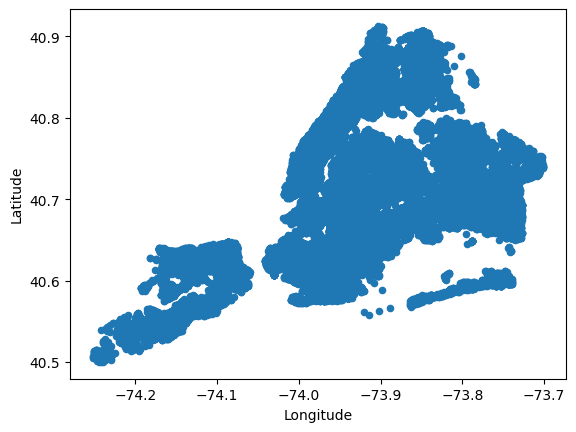

In [66]:
#11. Create atleast 2 to 3 visualizations
df.plot(kind="scatter",x="Longitude",y="Latitude")

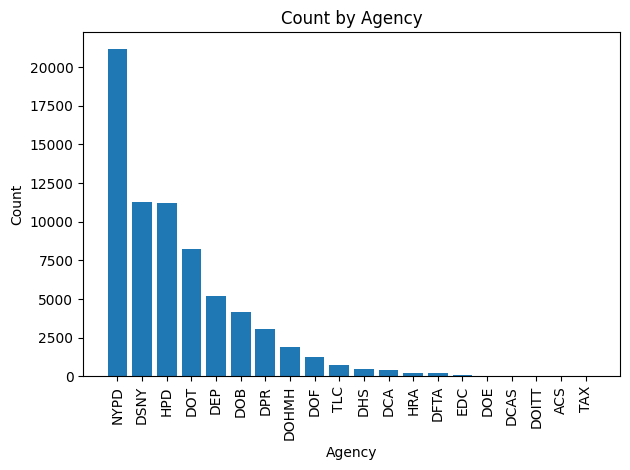

In [67]:
#11. Create atleast 2 to 3 visualizations
dept_counts = df['Agency'].value_counts()

plt.figure()
plt.bar(dept_counts.index, dept_counts.values)

plt.xlabel('Agency')
plt.ylabel('Count')
plt.title('Count by Agency')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



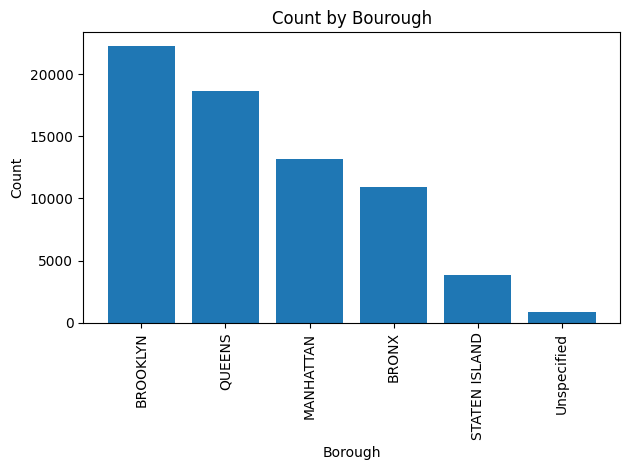

In [68]:
#11. Create atleast 2 to 3 visualizations
dept_counts = df['Borough'].value_counts()

plt.figure()
plt.bar(dept_counts.index, dept_counts.values)

plt.xlabel('Borough')
plt.ylabel('Count')
plt.title('Count by Bourough')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()